# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [105]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt 
import pandas as pd
import os 
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.linear_model import LogisticRegression

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#7298ce">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #d18753; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#d18753">**выборы**</font> и подбирать <font color="#d18753">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [68]:
pigments = ['#B85C38', '#E6B422', '#C04000', '#F28500'] 

In [69]:
train_df =  pd.read_csv("matches_df_train.csv")
test_df = pd.read_csv("matches_df_test.csv")

In [70]:
train_df.dtypes

match_id         int64
date            object
region          object
game_mode        int64
duration         int64
radiant_win       bool
avg_mmr        float64
dtype: object

In [71]:
train_df.shape



(641090, 7)

In [72]:
train_size_mb = os.path.getsize("matches_df_train.csv") / (1024 * 1024)
print(f"{train_size_mb:.6f} MB")

28.964462 MB


In [73]:
test_df.dtypes

match_id       int64
date          object
region        object
game_mode      int64
avg_mmr      float64
dtype: object

In [74]:
test_df.shape

(59748, 5)

In [75]:
test_size_mb = os.path.getsize("matches_df_test.csv") / (1024 * 1024)
print(f"{test_size_mb:.6f} MB")

2.081730 MB


Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

In [76]:
target_variable_column = "radiant_win"

train_df[target_variable_column].value_counts() 



radiant_win
True     327451
False    313639
Name: count, dtype: int64

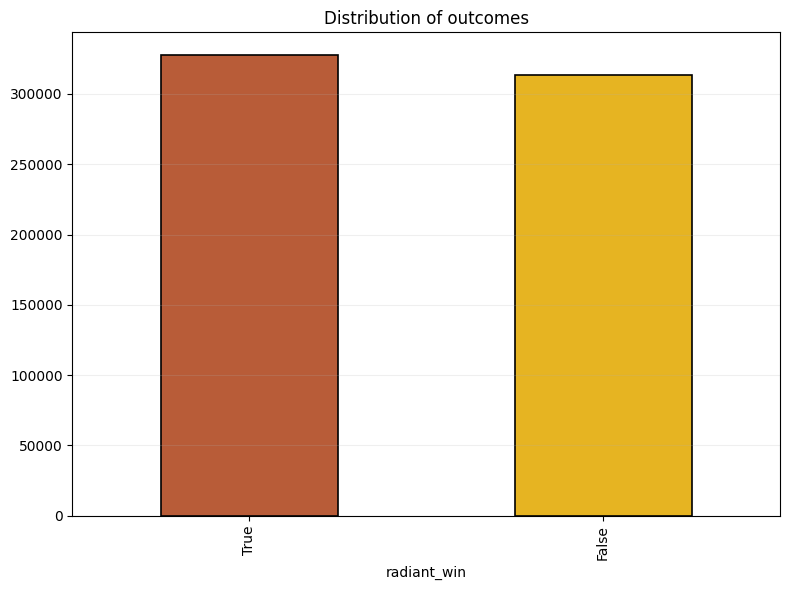

In [77]:
plt.figure(figsize=(8, 6))
train_df[target_variable_column].value_counts().plot(kind='bar',color=pigments, edgecolor='black', linewidth=1.2)
plt.title('Distribution of outcomes', fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:**
Метрика Gini кажется вполне подходящей. Как видно из представленных данных, значения метрик для класса находятся примерно на одном уровне. Поскольку Gini строится на основе ROC-AUC, она адекватно отражает качество классификации при таком распределении.

Однако если бы наблюдался сильный дисбаланс классов,  который не наблюдается, использование Gini могло бы привести к завышенной оценке. 
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

In [78]:
train_counts = train_df["region"].value_counts().sort_index()
test_counts = test_df["region"].value_counts().sort_index()

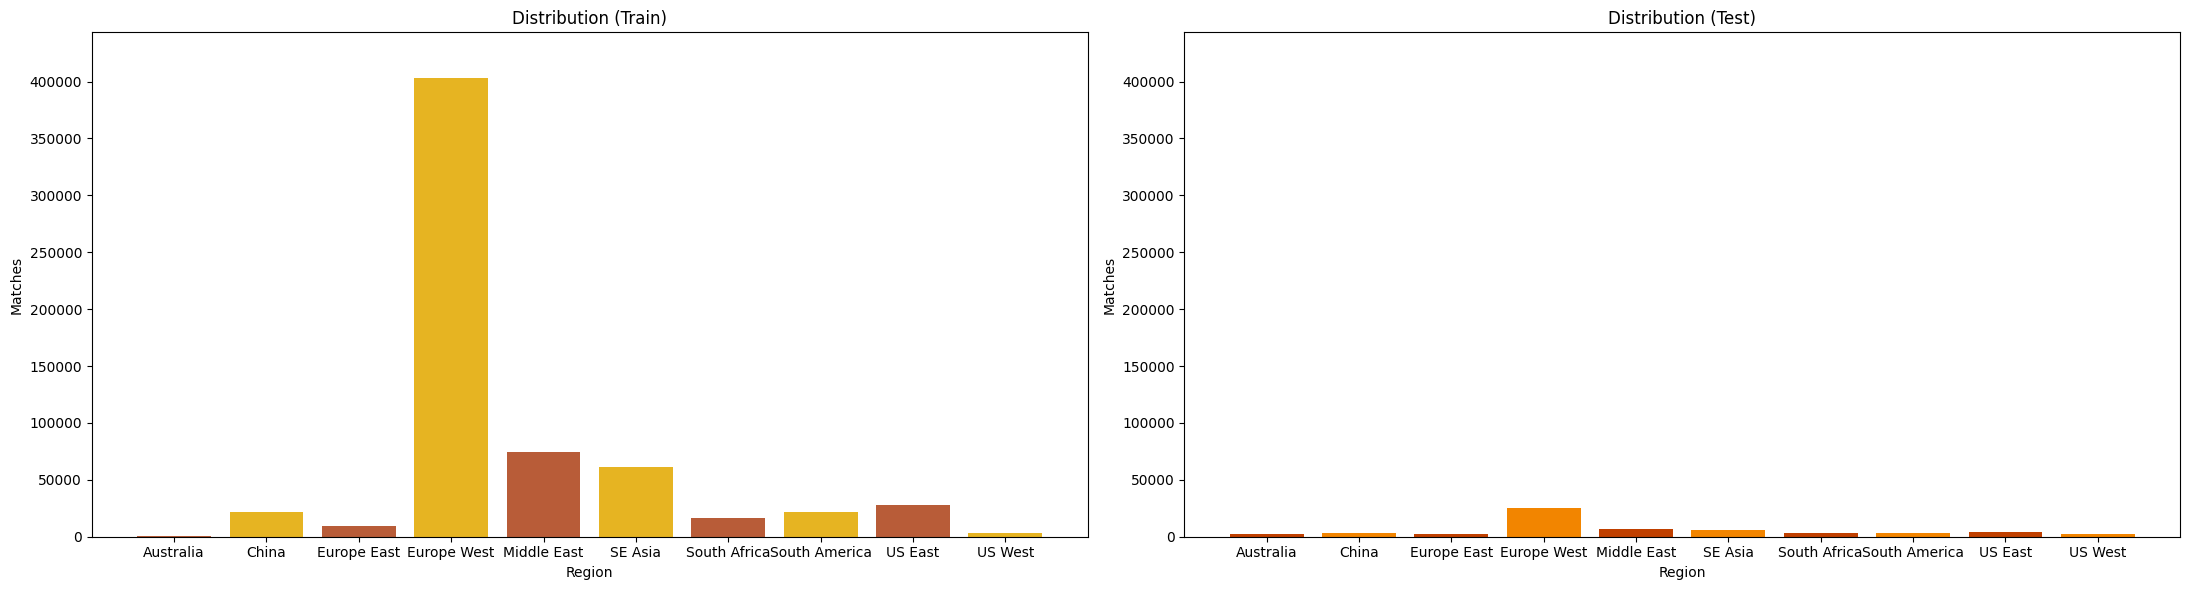

In [79]:
ig, axes = plt.subplots(1, 2, figsize=(22,6))

axes[0].bar(train_counts.index, train_counts.values, color = pigments[:2])
axes[0].set_title("Distribution (Train)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Matches")

axes[1].bar(test_counts.index, test_counts.values, color= pigments[2:])
axes[1].set_title("Distribution (Test)")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Matches")

max_value = max(max(train_counts.values), max(test_counts.values))

axes[0].set_ylim(0, max_value * 1.1) 
axes[1].set_ylim(0, max_value * 1.1)

plt.tight_layout()
plt.show()

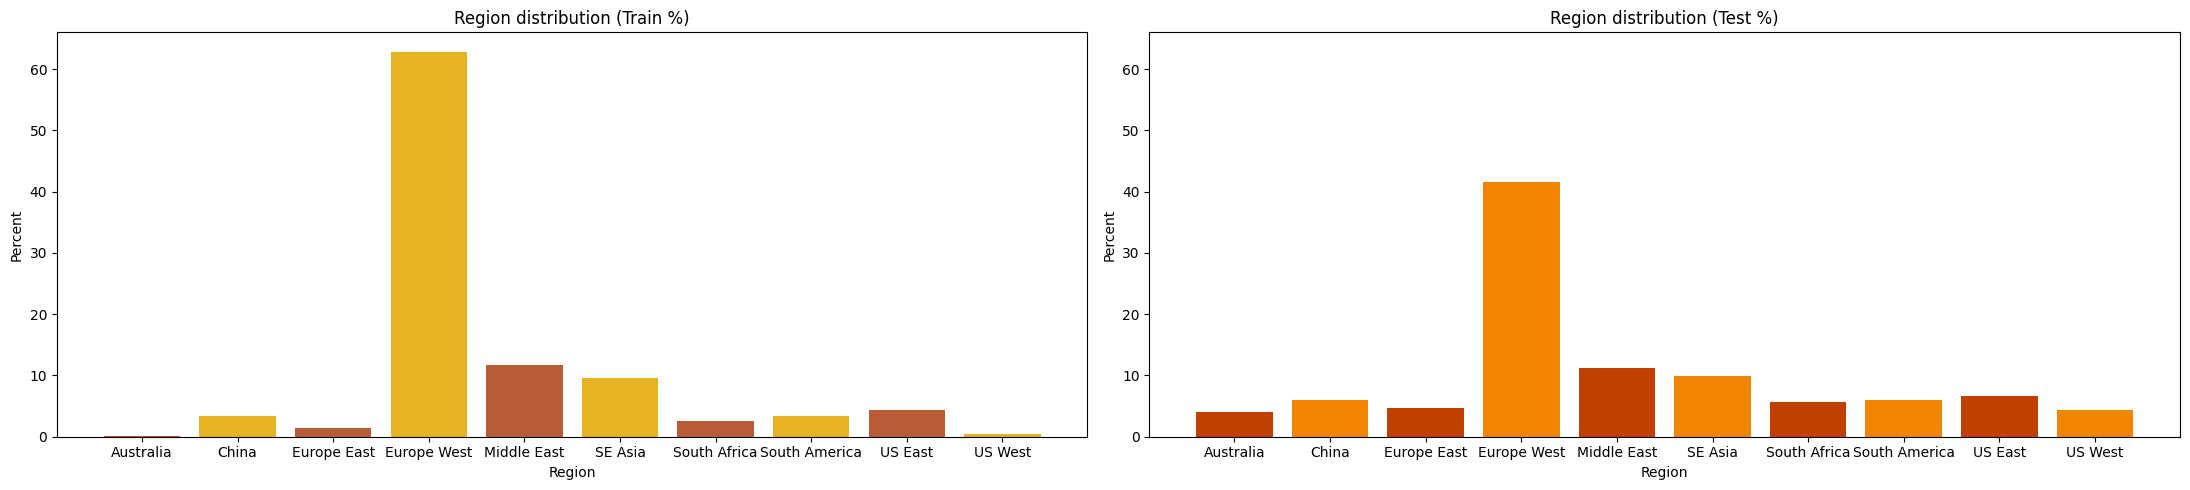

In [80]:
train_pct = train_df['region'].value_counts(normalize=True).sort_index() * 100
test_pct = test_df['region'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(22,5))

axes[0].bar(train_pct.index, train_pct.values, color = pigments[:2])
axes[0].set_title("Region distribution (Train %)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Percent")

axes[1].bar(test_pct.index, test_pct.values, color = pigments[2:])
axes[1].set_title("Region distribution (Test %)")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Percent")

max_pct = max(max(train_pct.values), max(test_pct.values))

axes[0].set_ylim(0, max_pct * 1.05)
axes[1].set_ylim(0, max_pct * 1.05)

plt.tight_layout()
plt.show()

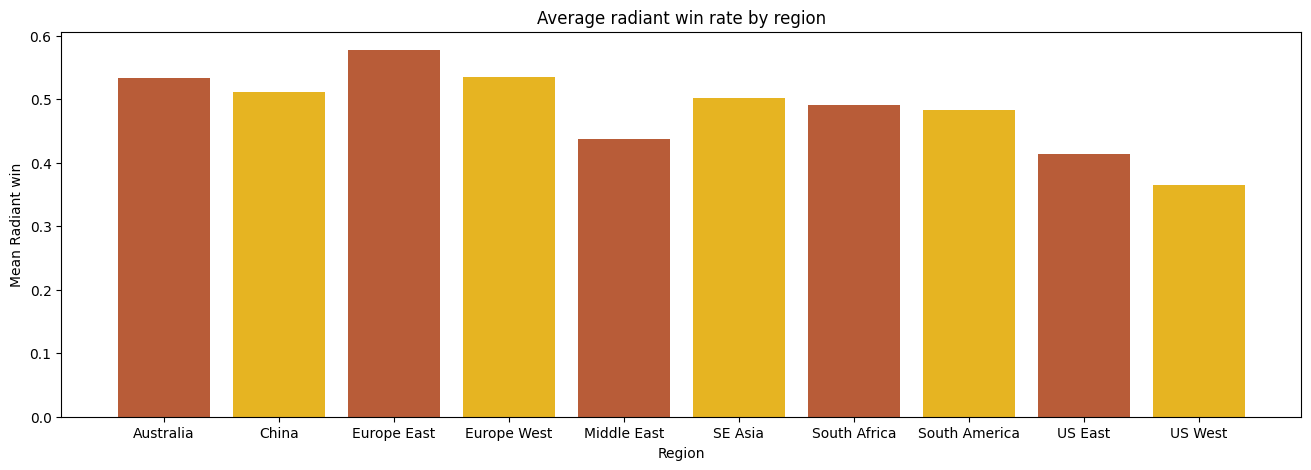

In [81]:
region_mean = train_df.groupby("region")["radiant_win"].mean().sort_index()

plt.figure(figsize=(16,5))

plt.bar(region_mean.index, region_mean.values, color = pigments[:2])
plt.title("Average radiant win rate by region")
plt.xlabel("Region")
plt.ylabel("Mean Radiant win")

plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**  
По графикам видно, что значительно больше всего матчей приходится на Западную Европу так как там прям существенный перевес, и на трейне, и на тесте остальные регионы просто уступают.

По поводу обучения считаю что модель обучить можно. Судя по цифрам, регион вполне влияет на исход: например, в Восточной Европе силы Света побеждают чаще примерно 60 процент побед, а вот в Западном США, наоборот, реже 40%. То есть зависимость прослеживается, и, скорее всего, модель сможет вытащить из этого признака полезный сигнал. 
</div>

Наша первая развилка — <font color="#d18753">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#d18753">**One-Hot Encoder**</font> | <font color="#d18753">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">
Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 
</div>

In [82]:
#!pip install -qU category-encoders

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:**
Мне больше всего нравиться one-hot encoder, это был первый про который я узнал на второй лекции, и чисто субьективно кажется что можно сказать больше про объект в зависимости от признаков к которым он принаджелит по сравнению с target encoder. 

</div>

Закодируйте колонку `region` выбранным вами способом

In [83]:
import category_encoders as ce

features = list(test_df.columns)

X_train = train_df[features]
y_train = train_df['radiant_win']
X_test = test_df[features]

encoder = ce.OneHotEncoder(cols=['region'], use_cat_names=True)

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

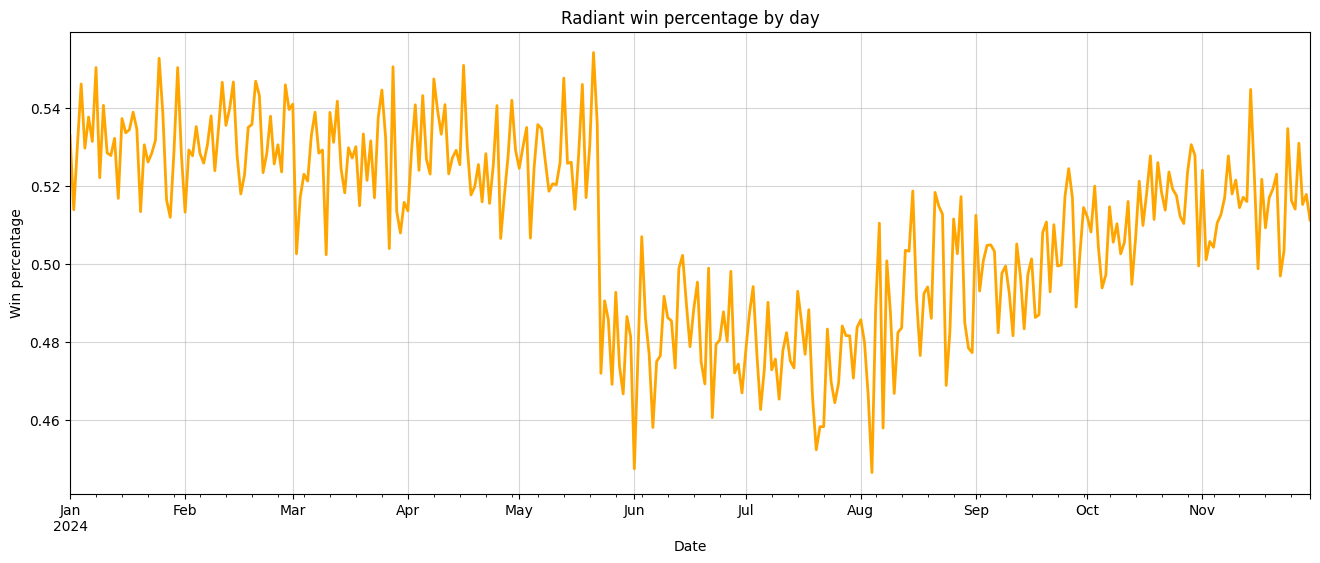

In [84]:
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

plt.figure(figsize=(16, 6))
train_df.groupby('date')['radiant_win'].mean().plot(color='orange', linewidth=2)
plt.title('Radiant win percentage by day')
plt.ylabel('Win percentage')
plt.xlabel('Date')
plt.grid(alpha=0.5)
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:**

Классический случай Datadrift, когда меняются внешние условия и модель, обученная на старых данных, перестает адекватно работать, потому что зависимости между признаками и целевой переменной по сути сдвинулись. 

Смотрим на график винрейта света по времени и сразу бросается в глаза что до конца мая всё было более-менее стабильно. Дальше ситуация постепенно выравнивалась, но уже с флуктуациями туда-сюда, и только к декабрю более-менее вернулась к привычным значениям. 

С чем связано падение? Тут всё упирается в патч 7.36 данной игрв, вышел который как раз в конце мая, где разрабы игрф  взяли и добавили каждому герою врожденные способности и аспекты. 

И вот тут важный момент: до этого патча у сил Света было небольшое, но стабильное преимущество за счет более удобного старта. А после патча новые механики, судя по всему, сыграли больше на руку силам Тьмыим.

Потом, конечно, разработчики начали балансить то что они сделали и постепенно ситуация стала возвращаться к исходной.


</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#d18753">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#d18753">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** 

Да, признаки, полученные из дат, необходимо кодировать. Если оставить их в исходном виде, модель может интерпретировать их как числовые значения с определённым порядком или весом. Например, она может ошибочно сказать что воскресенье имеет большее значение, чем понедельник, хотя дни недели не являются количественными величинами и между ними нет такой зависимости.

Для корректной работы модели признаки из даты следует преобразовать. В частности, можно выделить месяц и день недели. Месяц имеет смысл закодировать с помощью One-Hot Encoding, поскольку в разные месяцы могут происходить определённые изменения (например, обновления или события), которые могут влиять на поведение пользователей.

Также полезно учитывать день недели. Например, можно добавить бинарный признак, показывающий, является ли день выходным. Это связано с тем, что в выходные обычно наблюдается больший приток аудитории так как у людей больше свободного времени, поэтому возрастает онлайн-активность и количество действий в системе. В таком случае достаточно создать бинарную переменную (0 пусть будний день, 1 пусь выходной), и отдельное кодирование для субботы и воскресенья через One-Hot Encoding уже не потребуется.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [85]:
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

train_df['day'] = train_df['date'].dt.day
train_df['weekday'] = train_df['date'].dt.weekday

test_df['day'] = test_df['date'].dt.day
test_df['weekday'] = test_df['date'].dt.weekday

train_df['month'] = train_df['date'].dt.month
train_df['is_weekend'] = train_df['weekday'].isin([5, 6]).astype(int)

test_df['month'] = test_df['date'].dt.month
test_df['is_weekend'] = test_df['weekday'].isin([5, 6]).astype(int)

Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:**
Случайное разбиение может перемешать данные из прошлого и будущего. В результате модель получит информацию о будущих наблюдениях во время обучения, что приведёт к утечке данныx и завышенной оценке качества. Поэтому данные нужно делить по времени и обучать модель на более ранних наблюдениях, а проверять на более поздних. Это позволяет корректно оценить, как модель будет работать на новых данных.

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#d18753">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#d18753">**трешхолд**</font> `t` или <font color="#d18753">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [86]:
from sklearn.model_selection import TimeSeriesSplit
train_df = train_df.sort_values(by='date').reset_index(drop=True)
tscv = TimeSeriesSplit(n_splits=5)

И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#d18753">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#d18753">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#d18753"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#d18753"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#d18753"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#d18753"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#d18753"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#d18753">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#d18753">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#d18753">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но небольшой буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

train_df = train_df.sort_values('date')

def train_model(feature_list):
    X = train_df[feature_list]
    y = train_df['radiant_win']

    X = pd.get_dummies(X)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_tr)

    probs = clf.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, probs)
    gini = 2 * auc - 1

    print(f"ROC-AUC: {auc}, Gini: {gini}\n")


print("dates")
train_model(['month', 'weekday', 'is_weekend'])

print("regions")
train_model(['region'])

print("dates and regions")
train_model(['month', 'weekday', 'is_weekend', 'region'])

dates
ROC-AUC: 0.5005971501807664, Gini: 0.0011943003615328962

regions
ROC-AUC: 0.5368175379021543, Gini: 0.0736350758043085

dates and regions
ROC-AUC: 0.5368648047990402, Gini: 0.07372960959808039



<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:**
**Ответ:**
Даты практически не помогли улучшить качество модели, при добавлении дат качество увеличивается совсем незначитель. Разница очень маленькая, поэтому влияние дат можно считать минимальным.

В целом это ожидаемо, сами по себе признаки месяца, дня недели или выходного дня слабо связаны с исходом матча. Гораздо более важными являются игровые характеристики. Хотя такие признаки можно было бы не оставлять, так как они не сильно улучшают качество модели и лишь немного усложняют её, я все-же бы оставил, порадуясь улучешию метрики.

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

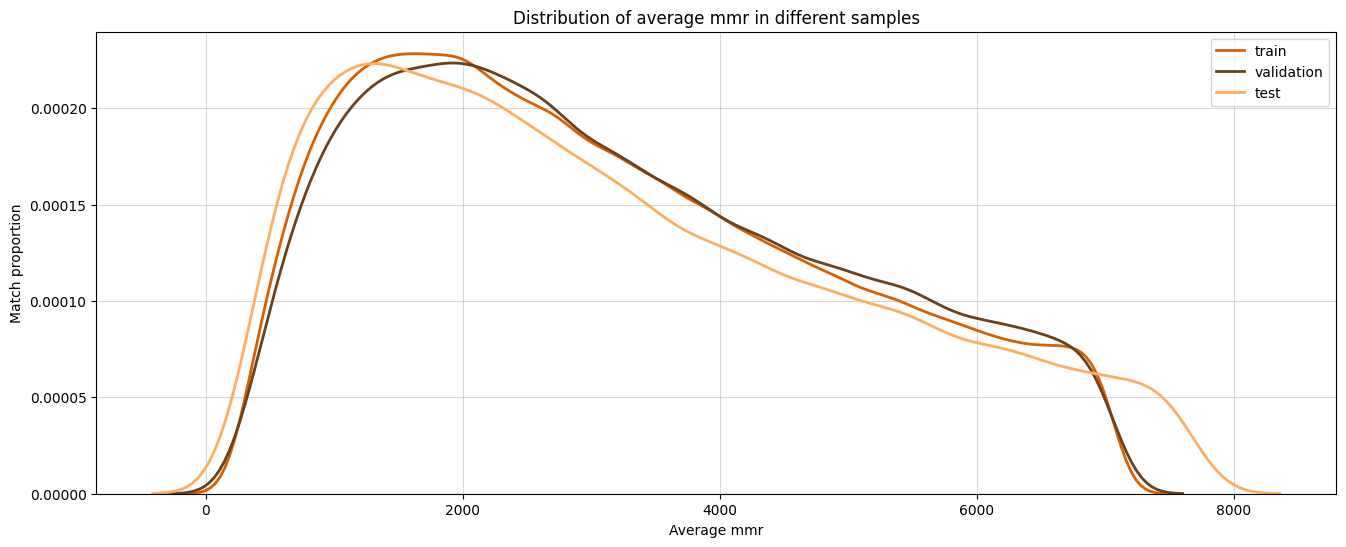

In [88]:
train_df = train_df.sort_values(by='date')

split_index = int(len(train_df) * 0.8)

train_part = train_df.iloc[:split_index]
val_part = train_df.iloc[split_index:]

plt.figure(figsize=(16, 6))

sns.kdeplot(train_part['avg_mmr'].dropna(), label='train', color='#d95f02', linewidth=2)
sns.kdeplot(val_part['avg_mmr'].dropna(), label='validation', color="#6a411c", linewidth=2)
sns.kdeplot(test_df['avg_mmr'].dropna(), label='test', color='#fdae61', linewidth=2)

plt.title('Distribution of average mmr in different samples')
plt.xlabel('Average mmr')
plt.ylabel('Match proportion')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:**
В целом распределение асимметричное, со смещением вправо и тяжёлысм правым хвостом. Основная масса значений сосредоточена в одной области, а затем постепенно уходит в сторону больших значений. Распределения train и test в целом очень похожи друг на друга, однако у тестовой выборки значения минимально сильнее смещены в сторону более высоких MMR.

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но на практике это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

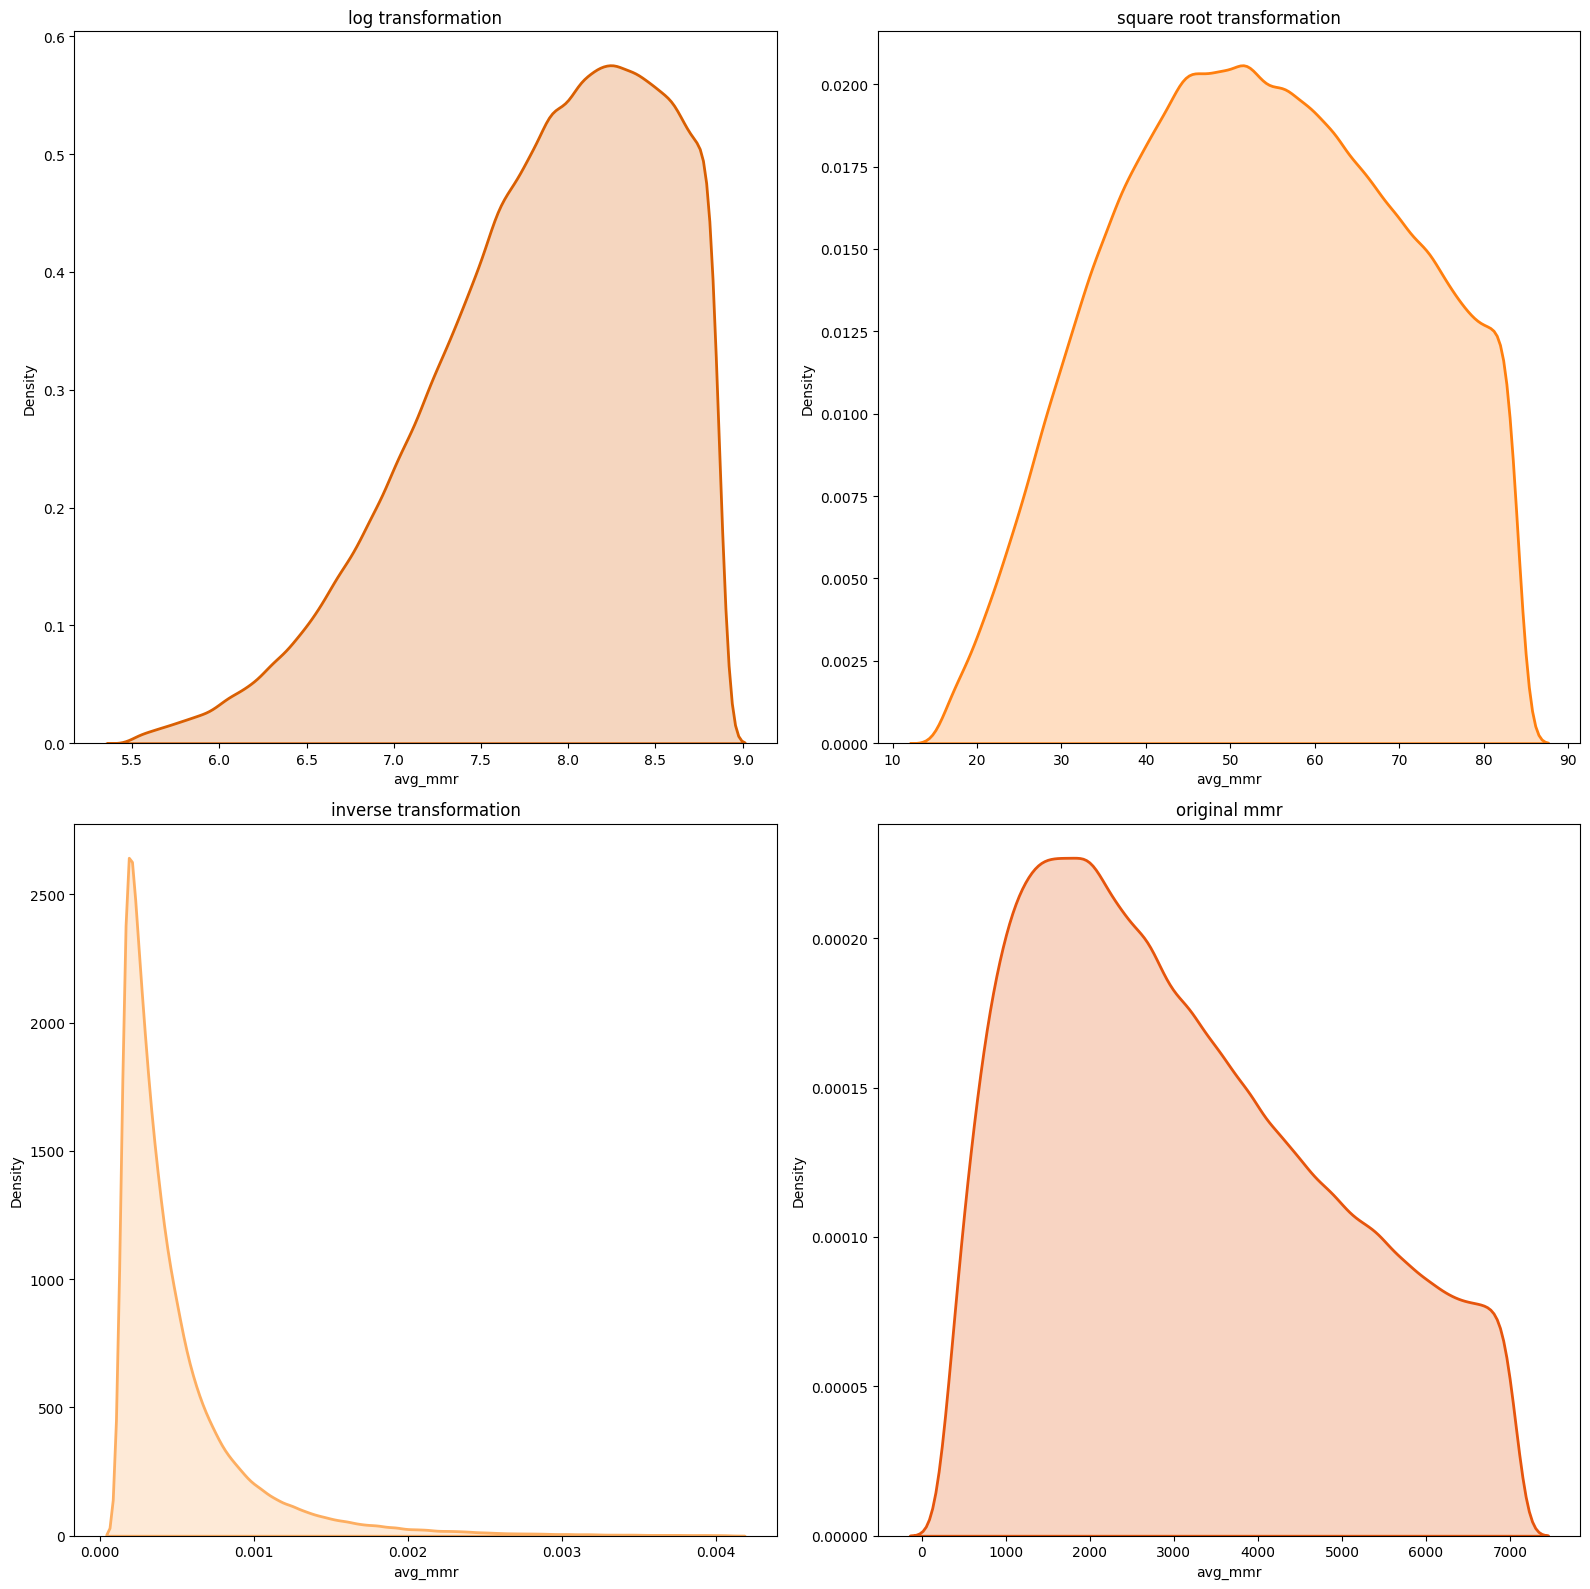

In [92]:
mmr = train_df['avg_mmr'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

sns.kdeplot(np.log1p(mmr), ax=axes[0, 0], fill=True, linewidth=2, color='#d95f02')
axes[0, 0].set_title('log transformation')

sns.kdeplot(np.sqrt(mmr), ax=axes[0, 1], fill=True, linewidth=2, color='#ff7f0e')
axes[0, 1].set_title('square root transformation')

sns.kdeplot(1 / (1 + mmr), ax=axes[1, 0], fill=True, linewidth=2, color='#fdae61')
axes[1, 0].set_title('inverse transformation')

sns.kdeplot(mmr, ax=axes[1, 1], fill=True, linewidth=2, color='#e6550d')
axes[1, 1].set_title('original mmr')

plt.tight_layout()
plt.show()

Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#d18753">**Можете**</font> замерить его влияние, если есть желание, может это полная дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:**

Заполнять пропуски нулём в данном случае не очень корректно. Ноль будет восприниматься моделью как реальное значение MMR, хотя на самом деле это просто отсутствие данных, и это может исказить распределение признака.

Более правильным решением будет заполнить пропуски средним значением MMR. 


</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на тесте

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на тесте \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [94]:
base_features = ['month', 'weekday', 'is_weekend', 'region']

mean_mmr = train_df['avg_mmr'].mean()

train_df['mmr_filled'] = train_df['avg_mmr'].fillna(mean_mmr)
train_df['mmr_log'] = np.log1p(train_df['mmr_filled'])

train_model(base_features + ['mmr_log'])

ROC-AUC: 0.5603584474874281, Gini: 0.12071689497485627



### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [96]:
player_df = pd.read_csv('player_df.csv')
print(player_df['account_id'].value_counts())

account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 196396904           1
 114402642           1
 71323248            1
 194966424           1
 34952633            1
Name: count, Length: 974931, dtype: int64


In [97]:
heroes_df = pd.read_csv('Constants.Heroes.csv')
print(heroes_df['id'].value_counts())

id
1      1
2      1
3      1
4      1
5      1
      ..
135    1
136    1
137    1
138    1
145    1
Name: count, Length: 126, dtype: int64


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** 
Можем позволить себе удалить матчи с подозрительными ид, если их количество очень небольшое по сравнению с общим объёмом данных. В таком случае потери информации будут минимальными и это не окажет заметного влияния на обучение модели. Иначе нельзя, ибо это будет катастрофа для датасета.

</div>

In [98]:
player_df['account_id'] = player_df['account_id'].replace({4294967295: np.nan, -1: np.nan})

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [101]:
heroes_in_matches = set(player_df['hero_id'].unique())
heroes_in_constants = set(heroes_df['id'].unique())

unknown_heroes = heroes_in_matches - heroes_in_constants


print(unknown_heroes)
print(len(unknown_heroes))

{np.int64(0)}
1


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [102]:
duplicate_hero_matches = set(
    player_df.loc[player_df.duplicated(subset=['match_id', 'hero_id'], keep=False), 'match_id']
)

zero_hero_matches = set(
    player_df.loc[player_df['hero_id'] == 0, 'match_id']
)

valid_accounts_df = player_df.dropna(subset=['account_id'])
spy_matches = set(
    valid_accounts_df.loc[valid_accounts_df.duplicated(subset=['match_id', 'account_id'], keep=False), 'match_id']
)

invalid_matches = duplicate_hero_matches | zero_hero_matches | spy_matches

player_df = player_df.query('match_id not in @invalid_matches')

relevant_matches = set(train_df['match_id']) | set(test_df['match_id'])
player_df = player_df[player_df['match_id'].isin(relevant_matches)]

player_df = player_df.assign(
    is_radiant=lambda x: x['player_slot'] < 128
)

team_composition = (
    player_df
    .groupby(['match_id', 'is_radiant'])
    .size()
    .unstack(fill_value=0)
)

valid_team_balance = team_composition[
    (team_composition[True] == 5) & 
    (team_composition[False] == 5)
].index

player_df = player_df[player_df['match_id'].isin(valid_team_balance)]
player_df = player_df.drop(columns=['is_radiant'])

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#d18753">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#d18753">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [103]:
from scipy.sparse import csr_array  # вам может понравиться

class HeroesEncoder:
    def __init__(self, player_df):
        self.player_df = player_df
        self.max_hero_id = int(player_df.hero_id.max())

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        m = X.match_id.values
        p = self.player_df[self.player_df.match_id.isin(m)]
        idx = {v: i for i, v in enumerate(m)}

        S = csr_array(
            (np.where(p.player_slot < 128, 1, -1),
             (p.match_id.map(idx), p.hero_id)),
            shape=(len(m), self.max_hero_id + 1)
        )

        df = pd.DataFrame.sparse.from_spmatrix(S, columns=[f'hero_{i}' for i in range(self.max_hero_id + 1)])
        df['match_id'] = m
        return df     

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [104]:
train_df['date'] = pd.to_datetime(train_df['date'])
train_df['month'] = train_df['date'].dt.month
train_df['weekday'] = train_df['date'].dt.weekday
train_df['is_weekend'] = (train_df['weekday'] >= 5).astype(int)

mean_mmr = train_df['avg_mmr'].mean()
train_df['mmr_filled'] = train_df['avg_mmr'].fillna(mean_mmr)
train_df['mmr_log'] = np.log1p(train_df['mmr_filled'])

encoder = HeroesEncoder(player_df)
heroes_df = encoder.transform(train_df)
train_full = train_df.merge(heroes_df, on='match_id', how='left')


def train_simple_model(features):
    X = train_full[features]
    y = train_full['radiant_win']

    categorical = [c for c in features if c in ['month', 'weekday', 'is_weekend', 'region']]
    X_encoded = pd.get_dummies(X, columns=categorical, sparse=True) if categorical else X
    
    split = int(len(X_encoded) * 0.8)
    X_train, X_val = X_encoded.iloc[:split], X_encoded.iloc[split:]
    y_train, y_val = y.iloc[:split], y.iloc[split:]
    
    model = LogisticRegression(max_iter=1000, solver='liblinear')
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    gini = 2 * auc - 1
    print(f"ROC-AUC: {auc:.4f}, Gini: {gini:.4f}")


hero_cols = [c for c in heroes_df.columns if c.startswith('hero_') and c != 'hero_0']
base_features = ['month', 'weekday', 'is_weekend', 'region', 'mmr_log']

print("Heroes only")
train_simple_model(hero_cols)

print("Heroes + base + MMR + others")
train_simple_model(base_features + hero_cols)

Heroes only
ROC-AUC: 0.6349, Gini: 0.2699
Heroes + base + MMR + others


c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


ROC-AUC: 0.6474, Gini: 0.2949


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняет данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#d18753">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать их со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #7298ce; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. \
<font color="#d18753">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#d18753"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \
Выбор, как всегда, в ваших руках.

</div>

In [106]:
import optuna

X = train_full[base_features + hero_cols]
y = train_full['radiant_win']
cat = [c for c in X.columns if c in ['month','weekday','is_weekend','region']]
X = pd.get_dummies(X, columns=cat, sparse=True) if cat else X
split = int(len(X)*0.8)
X_tr, X_val = csr_matrix(X.iloc[:split].values), csr_matrix(X.iloc[split:].values)
y_tr, y_val = y.iloc[:split], y.iloc[split:]

def gini(y_true,y_pred): return 2*roc_auc_score(y_true,y_pred)-1

def objective(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3,10.0,log=True),
        "solver": trial.suggest_categorical("solver", ["liblinear","lbfgs"]),
        "max_iter": trial.suggest_int("max_iter",50,200,step=50),
        "random_state":42
    }
    model = LogisticRegression(**params)
    model.fit(X_tr,y_tr)
    preds = model.predict_proba(X_val)[:,1]
    gini_valid = gini(y_val,preds)
    return gini_valid

study = optuna.create_study(direction="maximize")
study.optimize(objective, show_progress_bar=True, n_trials=25)

[I 2026-03-14 22:38:45,325] A new study created in memory with name: no-name-86a1d0c8-f947-45a7-9aee-beb5562d70de


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-14 22:38:51,520] Trial 0 finished with value: 0.2948940815436467 and parameters: {'C': 0.028243014658661848, 'solver': 'liblinear', 'max_iter': 50}. Best is trial 0 with value: 0.2948940815436467.
[I 2026-03-14 22:38:56,706] Trial 1 finished with value: 0.29489563220010595 and parameters: {'C': 9.21166737768672, 'solver': 'liblinear', 'max_iter': 150}. Best is trial 1 with value: 0.29489563220010595.
[I 2026-03-14 22:39:01,943] Trial 2 finished with value: 0.2948953731080093 and parameters: {'C': 2.3942116802679214, 'solver': 'liblinear', 'max_iter': 100}. Best is trial 1 with value: 0.29489563220010595.
[I 2026-03-14 22:39:09,183] Trial 3 finished with value: 0.2952188632273858 and parameters: {'C': 0.0010941970416023898, 'solver': 'lbfgs', 'max_iter': 200}. Best is trial 3 with value: 0.2952188632273858.
[I 2026-03-14 22:39:14,787] Trial 4 finished with value: 0.2948966865880567 and parameters: {'C': 0.16073363510051203, 'solver': 'liblinear', 'max_iter': 50}. Best is tria

c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[I 2026-03-14 22:39:26,694] Trial 6 finished with value: 0.29497217881726123 and parameters: {'C': 0.022094002095331272, 'solver': 'lbfgs', 'max_iter': 100}. Best is trial 3 with value: 0.2952188632273858.
[I 2026-03-14 22:39:31,070] Trial 7 finished with value: 0.2948947545986802 and parameters: {'C': 0.025410444049829166, 'solver': 'liblinear', 'max_iter': 200}. Best is trial 3 with value: 0.2952188632273858.
[I 2026-03-14 22:39:34,761] Trial 8 finished with value: 0.2947594228094319 and parameters: {'C': 0.005848017983650404, 'solver': 'liblinear', 'max_iter': 150}. Best is trial 3 with value: 0.2952188632273858.
[I 2026-03-14 22:39:40,038] Trial 9 finished with value: 0.2948965940551649 and parameters: {'C': 0.05193610973252848, 'solver': 'liblinear', 'max_iter': 200}. Best is trial 3 with value: 0.2952188632273858.
[I 2026-03-14 22:39:47,661] Trial 10 finished with value: 0.29517880184242906 and parameters: {'C': 0.001025755611093066, 'solver': 'lbfgs', 'max_iter': 200}. Best is t

...

[I 2026-03-14 22:41:05,937] Trial 19 finished with value: 0.2950083893728759 and parameters: {'C': 0.012183820715325904, 'solver': 'lbfgs', 'max_iter': 100}. Best is trial 13 with value: 0.29557692363511734.
[I 2026-03-14 22:41:14,317] Trial 20 finished with value: 0.29494654379714236 and parameters: {'C': 0.06901773260755653, 'solver': 'lbfgs', 'max_iter': 200}. Best is trial 13 with value: 0.29557692363511734.
[I 2026-03-14 22:41:31,051] Trial 21 finished with value: 0.29553430395921154 and parameters: {'C': 0.0031287470464427362, 'solver': 'lbfgs', 'max_iter': 150}. Best is trial 13 with value: 0.29557692363511734.


c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[I 2026-03-14 22:41:41,798] Trial 22 finished with value: 0.2954935729283277 and parameters: {'C': 0.009926593880806571, 'solver': 'lbfgs', 'max_iter': 150}. Best is trial 13 with value: 0.29557692363511734.
[I 2026-03-14 22:41:48,178] Trial 23 finished with value: 0.29552984533487536 and parameters: {'C': 0.0022313844002989918, 'solver': 'lbfgs', 'max_iter': 150}. Best is trial 13 with value: 0.29557692363511734.


c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[I 2026-03-14 22:41:54,725] Trial 24 finished with value: 0.2950380169437661 and parameters: {'C': 0.012536988780034385, 'solver': 'lbfgs', 'max_iter': 100}. Best is trial 13 with value: 0.29557692363511734.


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:**

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )